In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
df = pd.read_excel("JSTdatasetR6.xlsx")
df.head()

,year,country,iso,ifs,pop,rgdpmad,rgdpbarro,rconsbarro,gdp,iy,...,eq_capgain,eq_dp,eq_capgain_interp,eq_tr_interp,eq_dp_interp,bond_rate,eq_div_rtn,capital_tr,risky_tr,safe_tr
0,1870,Australia,AUS,193,1775.0,3273.239437,13.836157,21.449734,208.78,0.109266,...,-0.070045,0.071417,NaN,NaN,NaN,0.049118,0.066415,NaN,NaN,NaN
1,1871,Australia,AUS,193,1675.0,3298.507463,13.936864,19.930801,211.56,0.104579,...,0.041654,0.065466,NaN,NaN,NaN,0.048446,0.068193,NaN,NaN,NaN
2,1872,Australia,AUS,193,1722.0,3553.426249,15.044247,21.085006,227.40,0.130438,...,0.108945,0.062997,NaN,NaN,NaN,0.047373,0.069861,NaN,NaN,NaN
3,1873,Australia,AUS,193,1769.0,3823.629169,16.219443,23.254910,266.54,0.124986,...,0.083086,0.064484,NaN,NaN,NaN,0.046720,0.069842,NaN,NaN,NaN
4,1874,Australia,AUS,193,1822.0,3834.796926,16.268228,23.458050,287.58,0.141960,...,0.119389,0.063503,NaN,NaN,NaN,0.046533,0.071085,NaN,NaN,NaN


In [3]:
df.describe()

,year,ifs,pop,rgdpmad,rgdpbarro,rconsbarro,gdp,iy,cpi,ca,...,eq_capgain,eq_dp,eq_capgain_interp,eq_tr_interp,eq_dp_interp,bond_rate,eq_div_rtn,capital_tr,risky_tr,safe_tr
count,2718.00000,2718.000000,2667.000000,2666.000000,2664.000000,2561.000000,2.641000e+03,2425.000000,2.666000e+03,2.489000e+03,...,2.170000e+03,2169.000000,7.0,7.0,6.0,2381.000000,2163.000000,1830.000000,1854.000000,2247.000000
mean,1945.00000,148.333333,31439.397574,9155.064763,39.793748,42.133609,2.454826e+06,0.188838,4.191118e+01,-4.572271e+04,...,1.167935e+06,0.040949,1.0,1.0,1.0,0.054346,0.042763,0.099308,0.111523,0.051634
std,43.59701,24.165940,45898.993728,7976.190143,33.884462,32.274402,1.615548e+07,0.064621,5.689962e+01,7.670287e+05,...,5.440622e+07,0.017111,0.0,0.0,0.0,0.031442,0.017694,0.090360,0.110373,0.048357
min,1870.00000,111.000000,1675.000000,737.375497,3.263085,4.074400,1.250757e-11,0.017287,1.150362e-11,-1.687900e+07,...,-8.842261e-01,0.000000,1.0,1.0,1.0,-0.035316,0.000000,-0.232140,-0.238515,-0.152371
25%,1907.00000,132.000000,4866.650000,2873.047663,12.694448,15.650000,5.428200e+01,0.140980,2.526395e+00,-6.345947e+01,...,-5.496224e-02,0.030100,1.0,1.0,1.0,0.036000,0.032112,0.047950,0.051188,0.024857
50%,1945.00000,143.000000,10113.530000,5477.011227,23.056114,27.846700,1.810926e+03,0.194356,1.050679e+01,-3.300000e-02,...,4.175594e-02,0.040665,1.0,1.0,1.0,0.046100,0.042530,0.090982,0.102568,0.043005
75%,1983.00000,172.000000,45077.000000,14619.435708,65.770534,68.720000,5.038345e+04,0.230288,7.617557e+01,1.788000e+01,...,1.568719e-01,0.051569,1.0,1.0,1.0,0.063500,0.053196,0.137372,0.159925,0.067896
max,2020.00000,193.000000,329239.715278,45887.569802,147.282620,120.431162,2.070466e+08,0.546975,2.268252e+02,5.885998e+06,...,2.534419e+09,0.127113,1.0,1.0,1.0,0.237154,0.138189,1.144161,1.281639,0.408514


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])


housing_capgain_ipolated    2713
eq_dp_interp                2712
eq_tr_interp                2711
eq_capgain_interp           2711
rent_ipolated               2689
tbus                        1419
thh                         1344
capital_tr                   888
risky_tr                     864
bdebt                        853
housing_rent_rtn             809
housing_tr                   809
housing_rent_yd              797
unemp                        769
housing_capgain              673
hpnom                        668
JSTtrilemmaIV                645
eq_div_rtn                   555
eq_dp                        549
eq_capgain                   548
noncore                      488
safe_tr                      471
eq_tr                        455
bond_tr                      423
ltd                          419
tmort                        406
bill_rate                    367
lev                          365
bond_rate                    337
iy                           293
peg_base  

In [6]:
(df.isnull().mean() * 100).sort_values(ascending=False)


housing_capgain_ipolated    99.816041
eq_dp_interp                99.779249
eq_tr_interp                99.742458
eq_capgain_interp           99.742458
rent_ipolated               98.933039
tbus                        52.207506
thh                         49.448124
capital_tr                  32.671082
risky_tr                    31.788079
bdebt                       31.383370
housing_rent_rtn            29.764533
housing_tr                  29.764533
housing_rent_yd             29.323032
unemp                       28.292862
housing_capgain             24.760854
hpnom                       24.576895
JSTtrilemmaIV               23.730684
eq_div_rtn                  20.419426
eq_dp                       20.198675
eq_capgain                  20.161884
noncore                     17.954378
safe_tr                     17.328918
eq_tr                       16.740250
bond_tr                     15.562914
ltd                         15.415747
tmort                       14.937454
bill_rate   

Dropped columns due to missing values (>25%) or identifiers: ['eq_tr_interp', 'peg_base', 'eq_capgain_interp', 'bdebt', 'housing_capgain_ipolated', 'iso', 'thh', 'rent_ipolated', 'country', 'peg_type', 'housing_rent_yd', 'year', 'housing_tr', 'risky_tr', 'housing_rent_rtn', 'tbus', 'eq_dp_interp', 'crisisJST_old', 'capital_tr', 'ifs', 'unemp']
Selected features (37): ['pop', 'rgdpmad', 'rgdpbarro', 'rconsbarro', 'gdp', 'iy', 'cpi', 'ca', 'imports', 'exports', 'narrowm', 'money', 'stir', 'ltrate', 'hpnom', 'wage', 'debtgdp', 'revenue', 'expenditure', 'xrusd', 'tloans', 'tmort', 'lev', 'ltd', 'noncore', 'peg', 'peg_strict', 'JSTtrilemmaIV', 'eq_tr', 'bond_tr', 'bill_rate', 'housing_capgain', 'eq_capgain', 'eq_dp', 'bond_rate', 'eq_div_rtn', 'safe_tr']
Data shape after lag and dropna: (2651, 40)

Starting Rolling Window Validation...
Window 1970-1980: AUC=0.344, Recall=0.000 (Crisis Events in Test: 2)
Window 1980-1990: AUC=0.635, Recall=0.000 (Crisis Events in Test: 4)
Window 1990-2000: A

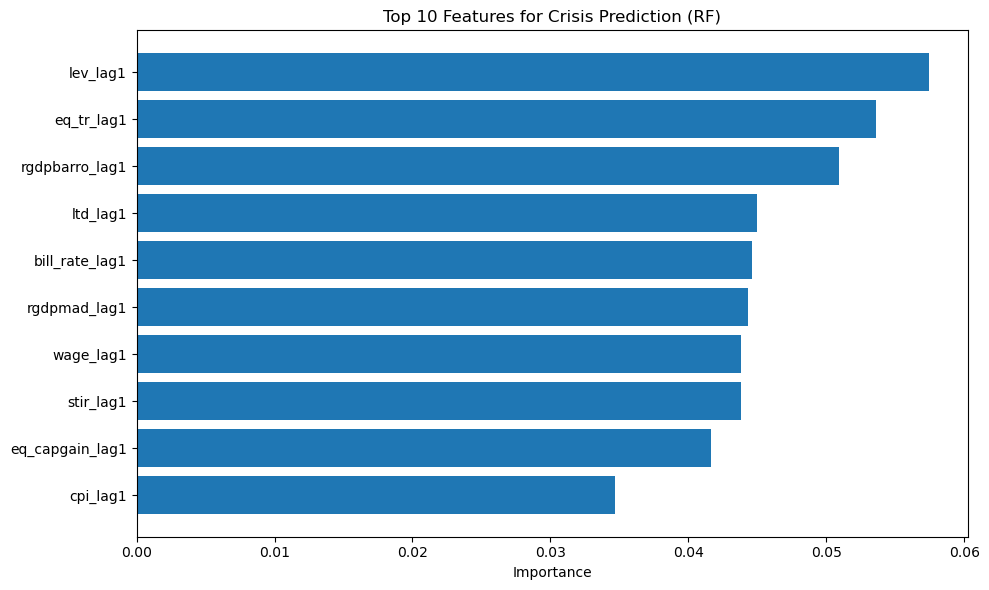

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.impute import SimpleImputer

# 1. Load Data
df = pd.read_excel("JSTdatasetR6.xlsx")

# 2. Preprocessing & Missing Values
# Target variable
target_col = 'crisisJST'

# Identify columns to drop (identifiers + future/leaky columns + sparse columns)
# Drop 'crisisJST_old' as it's a duplicate/old target
# Drop 'year', 'country', 'iso', 'ifs' from features, but keep 'year', 'country' for logic
identifiers = ['year', 'country', 'iso', 'ifs']
drop_cols = ['crisisJST_old', 'peg_type', 'peg_base'] # peg_type/base are categorical/objects

# Calculate missing percentage
missing_pct = df.isnull().mean()
# Threshold: Drop columns with > 25% missing values (Strict threshold to ensure quality)
high_missing_cols = missing_pct[missing_pct > 0.25].index.tolist()

# Combine cols to drop
cols_to_drop = list(set(identifiers + drop_cols + high_missing_cols))
# Ensure target is not dropped
if target_col in cols_to_drop:
    cols_to_drop.remove(target_col)

# Select features
feature_cols = [c for c in df.columns if c not in cols_to_drop and c != target_col]

print(f"Dropped columns due to missing values (>25%) or identifiers: {cols_to_drop}")
print(f"Selected features ({len(feature_cols)}): {feature_cols}")

# Imputation Strategy
# 1. Sort by Country and Year to ensure time order
df = df.sort_values(by=['country', 'year'])

# 2. Forward Fill within each country (propagates last known value)
# We apply this only to feature columns
df_imputed = df.copy()
df_imputed[feature_cols] = df.groupby('country')[feature_cols].ffill()

# 3. Fill remaining NaNs (e.g., start of dataset) with 0 or median
# For macro data, 0 might be misleading for indices, but okay for growth rates. 
# Let's use median of the column to be safe against outliers.
# (Code correction: perform median fill on the whole column after ffill)
for col in feature_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

# 3. Feature Engineering: Create Lags
# We want to predict Crisis(t) using X(t-1)
# Create a lagged version of features
X_lagged = df_imputed.groupby('country')[feature_cols].shift(1)
# Rename columns to indicate lag
X_lagged.columns = [f"{c}_lag1" for c in X_lagged.columns]

# Combine Target and Lagged Features
data_model = pd.concat([df_imputed[['year', 'country', target_col]], X_lagged], axis=1)

# Drop rows with NaN (generated by shifting)
data_model = data_model.dropna()

print(f"Data shape after lag and dropna: {data_model.shape}")

# 4. Rolling Window Validation
# We will manually implement an expanding window validation based on Years.
# Start training on 1870-1949, Predict 1950-1959
# Then Train 1870-1959, Predict 1960-1969... etc.

X = data_model.drop(['year', 'country', target_col], axis=1)
y = data_model[target_col]
years = data_model['year']

# Parameters for rolling window
start_year = 1970 # Start testing from 1970 (ensure enough history for training)
end_year = 2020
step_size = 10

results = []
importances = []

print("\nStarting Rolling Window Validation...")

# Loop through time windows
for test_start in range(start_year, end_year, step_size):
    test_end = test_start + step_size
    
    # Split Data
    # Train: All years < test_start
    # Test: test_start <= year < test_end
    
    train_mask = years < test_start
    test_mask = (years >= test_start) & (years < test_end)
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    # Check if we have both classes in train/test (robustness)
    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        print(f"Skipping window {test_start}-{test_end}: Insufficient class variety.")
        continue
    
    # Train Model
    # Using Balanced Class Weight to handle scarcity of crises
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        'Window': f"{test_start}-{test_end}",
        'AUC': auc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Train_Size': len(y_train),
        'Test_Crisis_Count': sum(y_test)
    })
    
    importances.append(clf.feature_importances_)
    print(f"Window {test_start}-{test_end}: AUC={auc:.3f}, Recall={rec:.3f} (Crisis Events in Test: {int(sum(y_test))})")

# 5. Summary Results
results_df = pd.DataFrame(results)
print("\nValidation Results Summary:")
print(results_df)

print(f"\nAverage AUC: {results_df['AUC'].mean():.3f}")

# 6. Feature Importance (Average over all folds)
avg_importance = np.mean(importances, axis=0)
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Predictors (Average Feature Importance):")
print(feat_imp_df.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(10), feat_imp_df['Importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Features for Crisis Prediction (RF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')